In [ ]:
!pip install shap


In [ ]:
import pandas as pd
import numpy as np
import os

In [ ]:
# 1. Setup the folder structure
os.makedirs('data/raw', exist_ok=True)

# 2. Direct URL to the raw CSV data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# 3. Define the column names (the raw file usually doesn't have them)
columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

# 4. Load from URL and save to our local folder
df = pd.read_csv(url, names=columns)
df.to_csv('data/raw/diabetes.csv', index=False)

print("✅ Success! The 'Source of Truth' is now in data/raw/diabetes.csv")

✅ Success! The 'Source of Truth' is now in data/raw/diabetes.csv


In [ ]:
# Load the data we just saved
df = pd.read_csv('data/raw/diabetes.csv')

# Look at the 'Summary Statistics'
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Visualize The Outliers


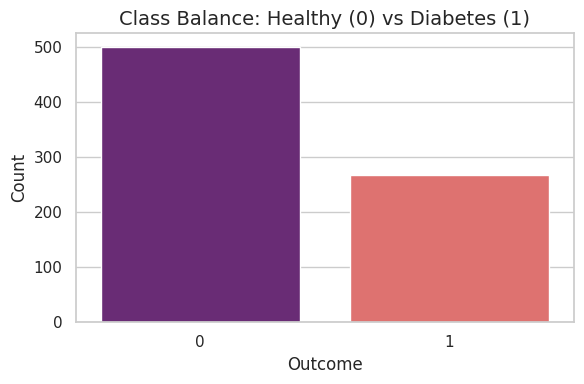

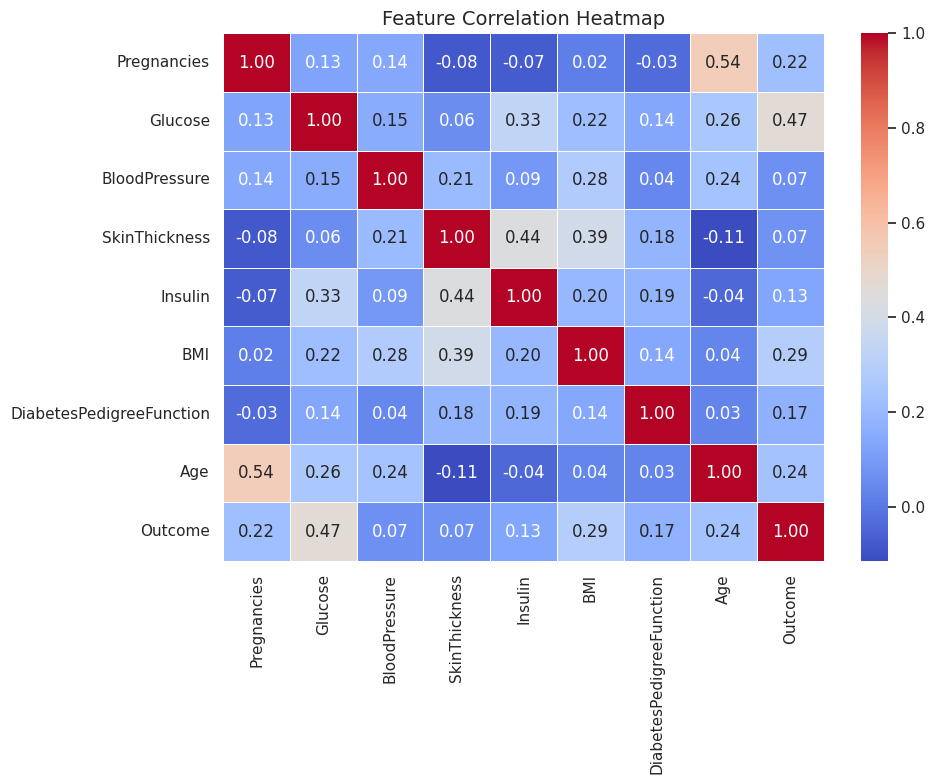

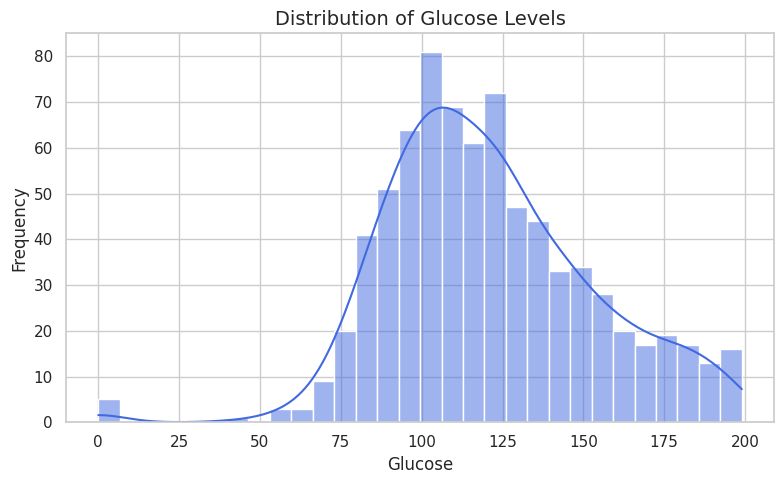

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Modern seaborn theme
sns.set_theme(style="whitegrid")

# ─────────────────────────────────────────────
# 1. Class Balance
# ─────────────────────────────────────────────
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Outcome",
    hue="Outcome",      # fixes future seaborn warning
    palette="magma",
    legend=False
)

plt.title("Class Balance: Healthy (0) vs Diabetes (1)", fontsize=14)
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 2. Correlation Heatmap
# ─────────────────────────────────────────────
plt.figure(figsize=(10, 8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=14)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 3. Glucose Distribution
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Glucose",
    kde=True,
    bins=30,
    color="royalblue"
)

plt.title("Distribution of Glucose Levels", fontsize=14)
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:

# 1. List the columns where '0' is biologically impossible
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. Tell the computer: 'These 0s are actually missing values (NaN)'
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

# 3. Fill the 'Missing' holes with the Median (the middle value)
df[cols_to_fix] = df[cols_to_fix].fillna(df[cols_to_fix].median())

# 4. The Verification: Check the 'min' row again
print("The new 'Minimum' values after surgery:")
print(df[cols_to_fix].min())

The new 'Minimum' values after surgery:
Glucose          44.0
BloodPressure    24.0
SkinThickness     7.0
Insulin          14.0
BMI              18.2
dtype: float64


**Grouping BMI and Age**


Why Group Numbers?
Imagine you are teaching a child (your AI) about weather.
Raw Data: Telling them it's 31.2°C, then 31.5°C, then 32.1°C. (This is too much detail).
Binning: Just telling them it's "Hot."

In [ ]:
# 1. Create BMI Categories
# Logic: Defined by medical standards
bins_bmi = [0, 18.5, 24.9, 29.9, 100]
labels_bmi = ['Underweight', 'Normal', 'Overweight', 'Obese']
df['BMI_Cat'] = pd.cut(df['BMI'], bins=bins_bmi, labels=labels_bmi)

# 2. Create Age Groups
# Logic: Risk stages in life
bins_age = [20, 30, 50, 100]
labels_age = ['Young', 'Middle', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age)

# 3. See our new 'Smart Features'
print(df[['BMI', 'BMI_Cat', 'Age', 'Age_Group']].head())

    BMI     BMI_Cat  Age Age_Group
0  33.6       Obese   50    Middle
1  26.6  Overweight   31    Middle
2  23.3      Normal   32    Middle
3  28.1  Overweight   21     Young
4  43.1       Obese   33    Middle


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Log Transform for 'Insulin' and 'SkinThickness' (to fix the skewness)
df['Insulin'] = np.log1p(df['Insulin'])
df['SkinThickness'] = np.log1p(df['SkinThickness'])

# 2. Scaling (The Level Playing Field)
scaler = StandardScaler()

# We only scale the numerical columns (not the words/categories we just made)
num_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Apply the scaler
df[num_cols] = scaler.fit_transform(df[num_cols])

# 3. See the results
print("Look at the values now - they are all small and balanced!")
print(df[num_cols].head())

Look at the values now - they are all small and balanced!
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.715064  0.018491  0.166619   
1    -0.844885 -1.205066      -0.528319       0.133506  0.018491 -0.852200   
2     1.233880  2.016662      -0.693761       0.133506  0.018491 -1.332500   
3    -0.844885 -1.073567      -0.528319      -0.578264 -0.552520 -0.633881   
4    -1.141852  0.504422      -2.679076       0.715064  0.612171  1.549303   

   DiabetesPedigreeFunction       Age  
0                  0.468492  1.425995  
1                 -0.365061 -0.190672  
2                  0.604397 -0.105584  
3                 -0.920763 -1.041549  
4                  5.484909 -0.020496  


In [ ]:
from imblearn.over_sampling import SMOTE


# 1. Encoding: Words ko Numbers mein convert karo (One-Hot Encoding)
# Isse 'Obese' ek column ban jayega jisme 0 ya 1 hoga.
df_final = pd.get_dummies(df, columns=['BMI_Cat', 'Age_Group'], drop_first=True)

# 2. X (Features) aur y (Target/Outcome) ko alag karo
X = df_final.drop('Outcome', axis=1)
y = df_final['Outcome']

# 3. SMOTE apply karo
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 4. Result check karo
print("Pehle ka balance:")
print(y.value_counts())
print("\nAb ka balance (After SMOTE):")
print(y_resampled.value_counts())

Pehle ka balance:
Outcome
0    500
1    268
Name: count, dtype: int64

Ab ka balance (After SMOTE):
Outcome
1    500
0    500
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# 2. Initialize the Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# 3. Train and Evaluate
print("Model Performance Results:\n")
for name, model in models.items():
    # Model ko train karo
    model.fit(X_train, y_train)

    # Bina dekhe huye data (Test set) par predict karo
    predictions = model.predict(X_test)

    # Score check karo
    accuracy = accuracy_score(y_test, predictions)
    print(f"{name} Accuracy: {accuracy:.2%}")

Model Performance Results:

Logistic Regression Accuracy: 75.50%
Random Forest Accuracy: 81.50%


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:10:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 75.50%


# 1. Cross Validation (Checking consistency)

All CV Scores: [0.76  0.745 0.795 0.925 0.865]
Mean CV Accuracy: 81.80%

--- Detailed Medical Report (Random Forest) ---
              precision    recall  f1-score   support

           0       0.84      0.78      0.81        99
           1       0.80      0.85      0.82       101

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200



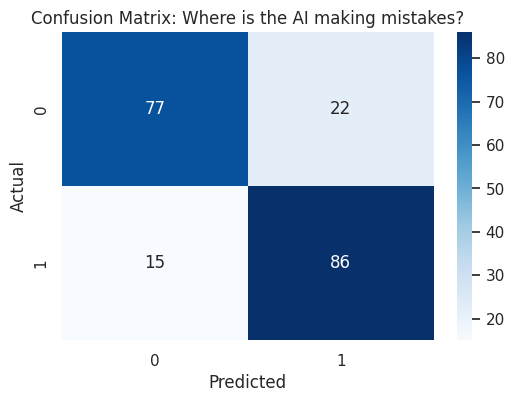

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


# Hum Random Forest par check karte hain kyunki wo abhi winner hai
cv_scores = cross_val_score(models["Random Forest"], X_resampled, y_resampled, cv=5)

print(f"All CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.2%}")

# 2. Detailed Report (Precision, Recall, F1)
rf_model = models["Random Forest"]
y_pred = rf_model.predict(X_test)

print("\n--- Detailed Medical Report (Random Forest) ---")
print(classification_report(y_test, y_pred))

# 3. Confusion Matrix (The 'Truth Table')
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Where is the AI making mistakes?')
plt.show()

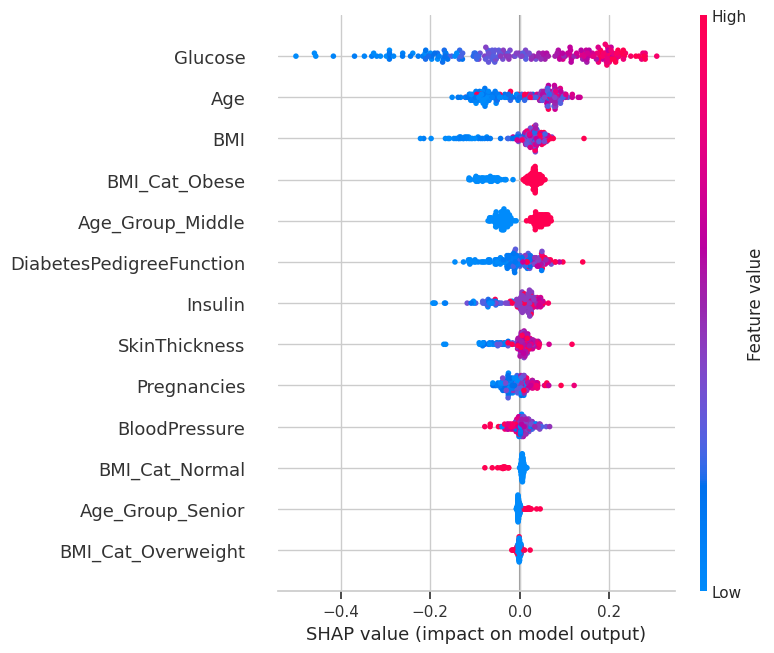

In [ ]:
import shap
import numpy as np

# 1. Explainer ko initialize karein (X_test pass karna zaroori hai naye versions mein)
explainer = shap.TreeExplainer(rf_model)

# 2. SHAP values calculate karein
# Hum check karenge ki output list hai ya array
shap_values = explainer.shap_values(X_test)

# 3. Shape mismatch fix karne ka logic
# Agar shap_values ek list hai (len=2), toh hum class 1 (Diabetes) uthayenge
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
else:
    # Kuch versions mein ye seedha 3D array hota hai [samples, features, classes]
    if len(shap_values.shape) == 3:
        shap_to_plot = shap_values[:, :, 1]
    else:
        shap_to_plot = shap_values

# 4. Ab plot karein (Feature names ke saath)
shap.summary_plot(shap_to_plot, X_test, feature_names=X_test.columns)

In [ ]:
import joblib

# 1. Save the Model
joblib.dump(rf_model, 'diabetes_model.pkl')

# 2. Save the Scaler (Taki hum naye patients ka data bhi sahi se scale kar sakein)
joblib.dump(scaler, 'scaler.pkl')

print("✅ Files Saved: 'diabetes_model.pkl' and 'scaler.pkl'")

✅ Files Saved: 'diabetes_model.pkl' and 'scaler.pkl'
